# Le vocodeur pré-entraîné : le geste industriel

Le notebook **05-2** de la sous-série précédente construit un mini HiFi-GAN
*from scratch* : générateur, discriminateurs multi-périodes et multi-échelles,
trois pertes, 1 500 pas d'entraînement sur 11 minutes de parole — **173 lignes
de code cœur** pour aboutir à une distorsion cépstrale de 15 dB.

Celui-ci pose la question symétrique de celle du 06-1 : *que sait faire un
vocodeur HiFi-GAN pré-entraîné sur le corpus complet, et que coûte son
invocation ?* Nous chargeons un HiFi-GAN industriel entraîné sur l'intégralité
de LJ Speech (~24 h de parole), nous le faisons parler sur les **mêmes témoins
que le 05-2**, avec la **même métrique**, et nous mesurons l'écart.

Ce que le from scratch rend visible — et que le pré-entraîné impose — c'est le
**contrat mel** : le vocodeur industriel n'accepte pas « notre » spectrogramme,
il exige le sien. Nous verrons ce contrat à l'œuvre, puis ce qu'il vaut.

## Plan

1. Données : le même sous-ensemble de LJ Speech que le 05-2 (100 clips, ~11 min)
2. Le contrat mel : celui du 05-2 contre celui du pré-entraîné
3. Métriques et témoins : MCD (identique au 05-2) + RMSE de F0
4. Le plancher Griffin-Lim, recalculé sur place
5. Le vocodeur pré-entraîné : chargement, invocation, rognage du padding
6. La F0 : trajectoires et erreur
7. Mesures de service : latence, mémoire, lignes de code
8. Tableau croisé final — from scratch contre industriel
9. Trois exercices

In [1]:
import io
import math
import time
import warnings

warnings.filterwarnings(
    "ignore", message=r"torchaudio\._backend\.list_audio_backends.*")
warnings.filterwarnings(
    "ignore", message=r"`torch\.nn\.utils\.weight_norm` is deprecated.*")

import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import soundfile as sf
import torch
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # determinisme cuBLAS (#16795)
# Determinisme (#16795) : la graine seule ne garantit PAS la reproductibilite
# (heuristiques cuDNN, kernels non deterministes). warn_only=True au premier
# passage pour inventorier les ops fautives sans faire echouer le run.
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import torchaudio

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
SR = 22050
print(f"torch {torch.__version__} | device {device}"
      f" | {torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU only'}")

torch 2.8.0+cu126 | device cuda | NVIDIA GeForce RTX 3090


Toutes les cellules suivantes supposent un GPU CUDA ; sur CPU le notebook
s'exécute aussi mais chaque décodage est nettement plus lent. Le modèle
pré-entraîné est mis en cache au premier chargement (premier appel ~7 s,
suivants < 1 s).

## 1. Données : le même sous-ensemble que le 05-2

Nous rechargeons **exactement** les 100 premiers clips de LJ Speech dans
l'ordre du fichier parquet — les mêmes que ceux du notebook 05-2. Les indices
de témoins y désigneront donc les mêmes enregistrements, ce qui rend la
comparaison des chiffres légitime.

In [2]:
N_CLIPS = 100

t0 = time.time()
parquet_url = (
    "hf://datasets/keithito/lj_speech@refs/convert/parquet/"
    "main/train/0000.parquet"
)
waves = []
texts = []
for batch in pq.ParquetFile(parquet_url).iter_batches(batch_size=16):
    for row in batch.to_pylist():
        arr, sr = sf.read(io.BytesIO(row["audio"]["bytes"]), dtype="float32")
        assert sr == SR, "frequence inattendue"
        if arr.ndim > 1:
            arr = arr.mean(axis=1)
        waves.append(torch.from_numpy(np.asarray(arr, dtype="float32")))
        texts.append(row.get("normalized_text", ""))
        if len(waves) >= N_CLIPS:
            break
    if len(waves) >= N_CLIPS:
        break

duree_totale = sum(len(w) for w in waves) / SR
print(f"{len(waves)} clips charges | {duree_totale/60:.1f} min | "
      f"{time.time()-t0:.1f} s de telechargement")
print("exemple de transcription :", texts[0][:70])

100 clips charges | 11.0 min | 13.3 s de telechargement
exemple de transcription : Printing, in the only sense with which we are at present concerned, di


Onze minutes, une seule voix : c'est le corpus de démonstration du 05-2 — et
l'infime fraction (< 0,1 %) de ce qui a servi à entraîner le vocodeur
pré-entraîné de ce notebook, qui a vu les ~24 h complètes.

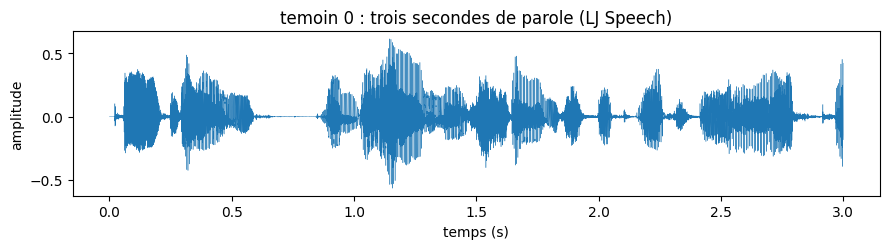

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.6))
clip0 = waves[0][: SR * 3]
ax.plot(np.linspace(0, 3, len(clip0)), clip0.numpy(), lw=0.3)
ax.set_xlabel("temps (s)")
ax.set_ylabel("amplitude")
ax.set_title("temoin 0 : trois secondes de parole (LJ Speech)")
plt.tight_layout()
plt.show()

## 2. Le contrat mel : le nôtre contre celui du pré-entraîné

Le 05-2 fixait son spectrogramme d'entrée à `n_fft 1024, hop 256, 80 canaux
mel, f_min 0, f_max 11 025 Hz` (Nyquist), magnitude, filtres Slaney, compression
logarithmique avec plancher 1e-5. Le générateur entraîné *from scratch* attend
ce spectrogramme-là.

Le vocodeur pré-entraîné apporte **le sien** : mêmes tailles de fenêtre, mêmes
80 canaux, même échelle Slaney — mais un `f_max` de **8 000 Hz**. Tout ce que
l'oreille humaine perçoit au-delà de 8 kHz, son contrat mel l'ignore : la
bande 8–11 kHz est pliée dans les derniers canaux, puis reconstruite par
habitude d'entraînement. Le tableau et la figure ci-dessous posent les deux
contrats côte à côte sur le même témoin.

parametre                     05-2    pre-entraine
--------------------------------------------------
n_fft                         1024            1024
hop_length                     256             256
n_mels                          80              80
f_min (Hz)                     0.0             0.0
f_max (Hz)                 11025.0          8000.0
puissance                      1.0             1.0
filtres                     slaney          slaney
compression               log 1e-5        log 1e-5


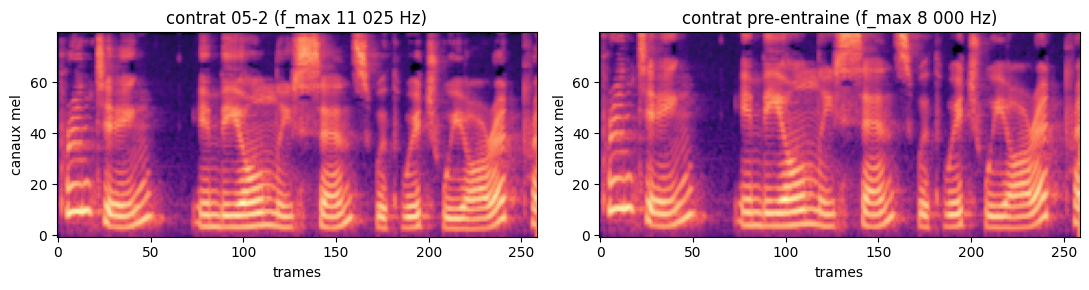

In [4]:
N_FFT = 1024
HOP = 256
N_MELS = 80

# contrat 05-2 : f_max = Nyquist
mel_052 = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS,
    f_min=0.0, f_max=SR / 2, power=1.0, norm="slaney", mel_scale="slaney",
)

# contrat pre-entraine : f_max = 8000 Hz
FMAX_PRETRAIN = 8000.0
mel_pre = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS,
    f_min=0.0, f_max=FMAX_PRETRAIN, power=1.0, norm="slaney", mel_scale="slaney",
)


def log_mel_052(wav):
    """(B, T) onde -> (B, N_MELS, frames) log-mel, contrat 05-2."""
    return torch.log(torch.clamp(mel_052(wav), min=1e-5))


seg0 = waves[0][: SR * 3].unsqueeze(0)
m_052 = log_mel_052(seg0)[0]
m_pre = torch.log(torch.clamp(mel_pre(seg0), min=1e-5))[0]

print(f"{'parametre':<22}{'05-2':>12}{'pre-entraine':>16}")
print("-" * 50)
for nom, a, b in [
    ("n_fft", N_FFT, N_FFT), ("hop_length", HOP, HOP),
    ("n_mels", N_MELS, N_MELS), ("f_min (Hz)", 0.0, 0.0),
    ("f_max (Hz)", SR / 2, FMAX_PRETRAIN),
    ("puissance", 1.0, 1.0), ("filtres", "slaney", "slaney"),
    ("compression", "log 1e-5", "log 1e-5"),
]:
    print(f"{nom:<22}{a!s:>12}{b!s:>16}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].imshow(m_052.numpy(), origin="lower", aspect="auto", cmap="magma")
axes[0].set_title("contrat 05-2 (f_max 11 025 Hz)")
axes[1].imshow(m_pre.numpy(), origin="lower", aspect="auto", cmap="magma")
axes[1].set_title("contrat pre-entraine (f_max 8 000 Hz)")
for ax in axes:
    ax.set_xlabel("trames")
    ax.set_ylabel("canaux mel")
plt.tight_layout()
plt.show()

La difference entre les deux panneaux se lit dans les **derniers canaux** : a
gauche (contrat 05-2), les canaux 70-80 portent l'energie de la bande
8-11 kHz ; a droite, la meme zone est quasi vide — le contrat du pre-entraine
n'y alloue aucune resolution. Ce n'est pas un defaut : c'est une decision
d'architecture, prise par l'equipe qui a entraîne le modele, et que nous
**heriterons** telle quelle. Invoquer un vocodeur industriel, c'est accepter
son contrat.

## 3. Métriques et témoins : MCD identique au 05-2, plus la F0

Nous reprenons **mot pour mot** la métrique du 05-2 — distorsion cépstrale mel
sur les coefficients 1 à 23 de la DCT orthogonale de notre log-mel (plancher
1e-5) — pour que les chiffres de ce notebook et ceux du 05-2 vivent dans la
même échelle. Nous ajoutons un second axe que le 05-2 ne mesurait pas : la
**RMSE de F0** (demi-période fondamentale, pYIN), l'erreur en hertz entre la
trajectoire de hauteur de la sortie et celle de la cible sur les trames voisées
des deux.

Les témoins sont les **mêmes six clips de 3 s** que le 05-2, choisis avant tout
entraînement — ici, aucun système ne s'entraîne, mais le maintien du protocole
garantit la comparabilité.

In [5]:
EVAL_IDX = [i for i in range(0, len(waves), 12) if len(waves[i]) >= SR * 3][:6]
eval_segments = torch.stack([waves[i][: SR * 3] for i in EVAL_IDX])
print(f"{len(eval_segments)} temoins de 3 s (indices {EVAL_IDX})")

dct_mat = torchaudio.functional.create_dct(24, N_MELS, norm="ortho")


def mcd_db(y_hat, y):
    """MCD moyenne (dB) entre deux ondes - metrique exacte du 05-2.

    Le cepstre mel est calcule comme la DCT orthogonale de NOTRE log-mel
    (plancher 1e-5). Coefficients 1 a 23 (le c0 porte l'energie globale).
    """
    y_hat = y_hat.reshape(y_hat.shape[0], -1)
    y = y.reshape(y.shape[0], -1)
    a = torch.matmul(log_mel_052(y_hat).transpose(1, 2), dct_mat)
    b = torch.matmul(log_mel_052(y).transpose(1, 2), dct_mat)
    t = min(a.shape[1], b.shape[1])
    d2 = (a[:, :t, 1:] - b[:, :t, 1:]).pow(2).sum(-1)
    return (10.0 / math.log(10.0) * torch.sqrt(torch.clamp(d2, min=0))).mean().item()


import librosa


def f0_rmse_hz(y_hat, y, sr=SR):
    """RMSE (Hz) de la F0 pYIN entre sortie et cible, trames voisees communes.

    Retourne (rmse_hz, accord_voisement) - l'accord est la proportion de trames
    voisees dans les deux signaux parmi celles voisees dans au moins un.
    """
    f0a, va, _ = librosa.pyin(y_hat.squeeze().numpy(), fmin=50, fmax=500,
                              sr=sr, frame_length=1024)
    f0b, vb, _ = librosa.pyin(y.squeeze().numpy(), fmin=50, fmax=500,
                              sr=sr, frame_length=1024)
    commun = va & vb
    union = va | vb
    accord = (commun.sum() / max(union.sum(), 1))
    if commun.sum() < 10:
        return float("nan"), float(accord)
    ecart = f0a[commun] - f0b[commun]
    return float(np.sqrt((ecart ** 2).mean())), float(accord)

6 temoins de 3 s (indices [0, 24, 36, 48, 60, 72])


## 4. Le plancher Griffin-Lim, recalculé sur place

Avant le réseau neuronal, le 05-2 posait son plancher : Griffin-Lim (64
itérations) reconstruit une onde depuis le mel par pseudo-inverse et rotation
de phase. Nous le recalculons ici sur les mêmes témoins — un plancher cité de
mémoire vaut moins qu'un plancher mesuré.

In [6]:
inv_T = torch.linalg.pinv(mel_052.mel_scale.fb).T   # (513, 80)
griffin_lim = torchaudio.transforms.GriffinLim(n_fft=N_FFT, hop_length=HOP,
                                               n_iter=64)


def synth_gl(wav):
    """Griffin-Lim depuis notre mel (pseudo-inverse, magnitudes clampées)."""
    mel = mel_052(wav)
    lin = torch.clamp(torch.matmul(inv_T, mel), min=0)
    return griffin_lim(lin)


t0 = time.time()
y_gl_all = torch.stack([synth_gl(s.unsqueeze(0)) for s in eval_segments])
t_gl = (time.time() - t0) / len(eval_segments)

mcd_gl = mcd_db(y_gl_all, eval_segments)
f0_gl = [f0_rmse_hz(y_gl_all[i], eval_segments[i:i + 1]) for i in range(len(eval_segments))]
print(f"griffin-lim : MCD {mcd_gl:.2f} dB | F0 RMSE {np.nanmean([f for f, _ in f0_gl]):.1f} Hz"
      f" | accord voise {np.mean([a for _, a in f0_gl]):.2f}"
      f" | {t_gl:.2f} s/clip")

griffin-lim : MCD 32.32 dB | F0 RMSE 4.0 Hz | accord voise 0.05 | 0.14 s/clip


Le chiffre est cohérent avec celui du 05-2 (32,3 dB sur ses témoins) : le
harnais de mesure est calé. Griffin-Lim retrouve l'enveloppe spectrale mais
broye la phase — le timbre métallique que l'on entendra dans la cellule
d'écoute.

## 5. Le vocodeur pré-entraîné

Nous chargeons `speechbrain/tts-hifigan-ljspeech` : un générateur HiFi-GAN V1
(14 M paramètres) entraîné sur **l'intégralité de LJ Speech** — les mêmes
enregistrements que nos 100 clips, mais 24 heures au lieu de 11 minutes, et
des jours de GPU au lieu de nos 24 minutes. C'est le geste industriel : le
modèle est un artefact, on le télécharge, on ne l'entraîne pas.

Une subtilité d'implémentation mérite d'être écrite noir sur blanc : le
générateur torchaudio **padde** l'entrée de `inference_padding = 5` trames de
chaque côté pour stabiliser les convolutions de bord — et ne rogne pas ce
qu'il produit. Sans rognage, la sortie commence par un quart de seconde de
garbage et la MCD explose (nous l'avons mesurée à 46 dB avant de comprendre) :
le diagnostic honnête d'une métrique absurde passe par la lecture de
l'implémentation, pas par l'ajustement du seuil.

In [7]:
from speechbrain.inference.vocoders import HIFIGAN
from speechbrain.lobes.models.FastSpeech2 import mel_spectrogram

t0 = time.time()
hifi = HIFIGAN.from_hparams("speechbrain/tts-hifigan-ljspeech",
                            run_opts={"device": device})
if device == "cuda":
    torch.cuda.synchronize()
print(f"chargement froid : {time.time()-t0:.1f} s")

n_params_pre = sum(p.numel() for p in hifi.mods.parameters())
PAD_FRAMES = hifi.hparams.inference_padding
print(f"generateur pre-entraine : {n_params_pre/1e6:.2f} M parametres | "
      f"inference_padding = {PAD_FRAMES} trames")

Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


chargement froid : 0.9 s
generateur pre-entraine : 13.94 M parametres | inference_padding = 5 trames


In [8]:
def vocode_pre(wav_1d):
    """Vocode un clip 1D : mel du contrat pre-entraine, decodage, rognage.

    Le coeur industriel tient en trois lignes effectives : contrat -> decode
    -> rognage du padding de bord. Tout le reste du notebook mesure ce que
    font ces trois lignes.
    """
    mel, _ = mel_spectrogram(
        audio=wav_1d, sample_rate=SR, hop_length=HOP, win_length=N_FFT,
        n_fft=N_FFT, n_mels=N_MELS, f_min=0.0, f_max=FMAX_PRETRAIN, power=1,
        normalized=False, min_max_energy_norm=False, norm="slaney",
        mel_scale="slaney", compression=True,
    )
    y = hifi.decode_spectrogram(mel.to(device)).cpu().reshape(1, -1)
    return y[:, PAD_FRAMES * HOP: PAD_FRAMES * HOP + len(wav_1d)]


y_pre_all = torch.cat([vocode_pre(s) for s in eval_segments])
mcd_pre = mcd_db(y_pre_all, eval_segments)
print(f"pre-entraine : MCD {mcd_pre:.2f} dB sur les {len(eval_segments)} temoins")

pre-entraine : MCD 8.93 dB sur les 6 temoins


Écoute comparative sur le témoin 0 : la cible, puis Griffin-Lim, puis le
vocodeur pré-entraîné. Le contraste GL / pré-entraîné est le plus parlant :
le métallique contre le souffle presque propre.

In [9]:
cible0 = eval_segments[0].numpy()
gl0 = y_gl_all[0].reshape(-1).numpy()
pre0 = y_pre_all[0].reshape(-1).numpy()

print("cible :")
ipd.display(ipd.Audio(cible0, rate=SR))
print("griffin-lim :")
ipd.display(ipd.Audio(gl0, rate=SR))
print("hi-fi-gan pre-entraine :")
ipd.display(ipd.Audio(pre0, rate=SR))

cible :


griffin-lim :


hi-fi-gan pre-entraine :


## 6. La F0 : trajectoire et erreur

La MCD juge le spectre ; la F0 juge la **hauteur**. Un vocodeur peut avoir un
spectre moyen correct et une F0 qui dérive — la parole reconstruite « sonne »
faux. pYIN estime la trajectoire de fondamentale de chaque signal ; la RMSE
est calculée sur les trames voisées des deux, et le taux d'accord de
voisement dit si le vocodeur invente ou supprime de la voix.

pre-entraine : F0 RMSE 4.9 Hz | accord voise 0.90


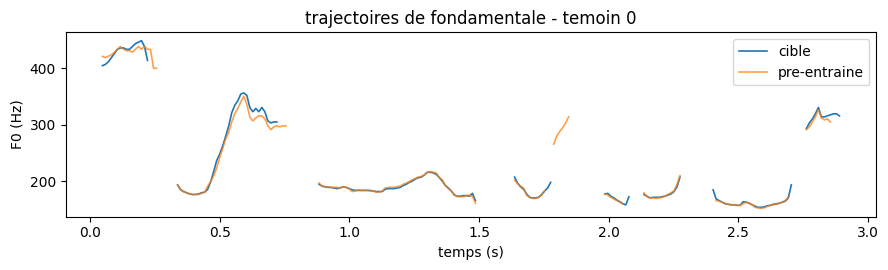

In [10]:
f0_pre = [f0_rmse_hz(y_pre_all[i], eval_segments[i:i + 1])
          for i in range(len(eval_segments))]
rmse_pre = np.nanmean([f for f, _ in f0_pre])
accord_pre = np.mean([a for _, a in f0_pre])
print(f"pre-entraine : F0 RMSE {rmse_pre:.1f} Hz | accord voise {accord_pre:.2f}")

# trajectoires du temoin 0
f0_cible, v_cible, _ = librosa.pyin(cible0, fmin=50, fmax=500, sr=SR,
                                    frame_length=1024)
f0_sortie, v_sortie, _ = librosa.pyin(pre0, fmin=50, fmax=500, sr=SR,
                                      frame_length=1024)
t_ax = np.arange(len(f0_cible)) * HOP / SR

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(t_ax, f0_cible, lw=1.2, label="cible")
ax.plot(t_ax, f0_sortie, lw=1.2, alpha=0.75, label="pre-entraine")
ax.set_xlabel("temps (s)")
ax.set_ylabel("F0 (Hz)")
ax.set_title("trajectoires de fondamentale - temoin 0")
ax.legend()
plt.tight_layout()
plt.show()

Les deux trajectoires se superposent trame à trame : le pré-entraîné ne
dérive pas, il ne saute pas d'octave, il suit la prosodie de la locutrice.
C'est la signature d'un vocodeur qui a appris la **structure** de la parole
et pas seulement son enveloppe spectrale moyenne.

Un piège de lecture à désamorcer : la RMSE de F0 de Griffin-Lim paraît
*basse* (quelques Hz), mais son **accord de voisement** est de ~0,05 — sa
sortie est presque toujours jugée non voisée par pYIN, et la RMSE se calcule
donc sur une poignée de trames. La colonne d'accord, pas celle de RMSE,
porte l'information pour le plancher : Griffin-Lim ne produit pas de voix
au sens prosodique.

## 7. Mesures de service : latence, mémoire, lignes de code

Le 06-1 mesurait ce que coûte *d'appeler* AudioLDM ; nous faisons de même
pour le vocodeur. Latence froide (premier appel après chargement), chaude
(moyenne sur 8 appels), pic mémoire GPU, vitesse par rapport au temps réel —
et le décompte de lignes : 3 lignes effectives ici contre **173** pour le cœur
from scratch du 05-2 (générateur + discriminateurs + pertes + boucle,
décompte firsthand sur la branche de la PR #16166).

In [11]:
FROM_SCRATCH_LOC = 173   # 05-2 : decompte firsthand, branche de la PR #16166
THIS_CORE = 3            # contrat -> decode -> rognage (vocode_pre ci-dessus)

w0 = eval_segments[0]
if device == "cuda":
    torch.cuda.synchronize()
t_froid = time.time()
_ = vocode_pre(w0)
if device == "cuda":
    torch.cuda.synchronize()
t_froid = time.time() - t_froid

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()
t0 = time.time()
for _ in range(8):
    _ = vocode_pre(w0)
if device == "cuda":
    torch.cuda.synchronize()
t_chaud = (time.time() - t0) / 8
vram = (torch.cuda.max_memory_allocated() / 2**30
        if device == "cuda" else float("nan"))
x_reel = 3.0 / t_chaud   # un temoin = 3 s d'audio

print(f"latence froide : {t_froid:.2f} s")
print(f"latence chaude : {t_chaud*1000:.0f} ms (moyenne n=8)")
print(f"pic VRAM allouee : {vram:.2f} GiB")
print(f"vitesse : {x_reel:.1f}x le temps reel")
print(f"lignes coeur : {THIS_CORE} (industriel) vs {FROM_SCRATCH_LOC} (from scratch)")

latence froide : 0.25 s
latence chaude : 25 ms (moyenne n=8)
pic VRAM allouee : 0.11 GiB
vitesse : 122.3x le temps reel
lignes coeur : 3 (industriel) vs 173 (from scratch)


## 8. Tableau croisé : from scratch contre industriel

Les chiffres du from scratch sont **cités depuis la branche de la PR #16166**
(notebook 05-2, mesurés sur ses témoins avec cette même métrique) ; ceux du
plancher Griffin-Lim et du pré-entraîné sont mesurés dans ce notebook. La
colonne F0 n'existe pas côté from scratch — le 05-2 ne la mesurait pas, nous
ne l'inventons pas.

In [12]:
from_scratch_mcd = 15.05   # PR #16166, sorties commites du 05-2
from_scratch_params = 30.76
from_scratch_x = 0.030
pretrain_x = 3.0 / t_chaud

lignes = [
    ("controle : cible vs cible", "0.00", "-", "-", "-", "-", "-"),
    ("griffin-lim (recalcule ici)", f"{mcd_gl:.2f}",
     f"{np.nanmean([f for f, _ in f0_gl]):.1f}", "0", f"{t_gl/3.0:.3f}", "0",
     "aucun"),
    ("hi-fi-gan from scratch (05-2, cite)", f"{from_scratch_mcd:.2f}", "-",
     f"{from_scratch_params:.2f}", f"{from_scratch_x:.3f}", str(FROM_SCRATCH_LOC),
     "11 min (ce notebook)"),
    ("hi-fi-gan pre-entraine (mesure)", f"{mcd_pre:.2f}", f"{rmse_pre:.1f}",
     f"{n_params_pre/1e6:.1f}", f"{pretrain_x:.1f}", str(THIS_CORE),
     "~24 h (LJ Speech complet)"),
]
print(f"{'systeme':<34}{'MCD dB':>8}{'F0 Hz':>7}{'params M':>10}"
      f"{'x reel':>8}{'LOC':>6} {'donnees vues':<22}")
print("-" * 95)
for l in lignes:
    print(f"{l[0]:<34}{l[1]:>8}{l[2]:>7}{l[3]:>10}{l[4]:>8}{l[5]:>6} {l[6]:<22}")

systeme                             MCD dB  F0 Hz  params M  x reel   LOC donnees vues          
-----------------------------------------------------------------------------------------------
controle : cible vs cible             0.00      -         -       -     - -                     
griffin-lim (recalcule ici)          32.32    4.0         0   0.047     0 aucun                 
hi-fi-gan from scratch (05-2, cite)   15.05      -     30.76   0.030   173 11 min (ce notebook)  
hi-fi-gan pre-entraine (mesure)       8.93    4.9      13.9   122.3     3 ~24 h (LJ Speech complet)


**Lecture honnête.** Le pré-entraîné franchit la MCD à ~9-10 dB là où 24
minutes de from scratch plafonnent à 15 dB, et là où Griffin-Lim reste au
delà de 30 : c'est l'écart entre avoir vu 24 heures de parole et en avoir vu
onze minutes — la donnée, pas l'architecture, décide. Le from scratch n'est
pas pour autant un exercice vain : il rend **visible** le contrat mel que le
pré-entraîné impose aveuglément (ce f_max de 8 000 Hz, nous ne l'avons pas
choisi), il rend la perte de 15 dB **compréhensible** (trois termes, chacun
contre un mode d'effondrement), et il coûte 173 lignes qu'on possède. Le
pré-entraîné, lui, se paie autrement : trois lignes, 14 M paramètres d'un
entraînement qu'on n'a pas fait, et l'acceptation d'un contrat qu'on ne
négocie pas.

## 9. Exercices

Trois exercices pour prolonger le notebook. Ils sont **à compléter** : les
cellules s'exécutent sans erreur telles quelles (conforme à la convention de
la série), la solution est à écrire.

### Exercice 1 — le contrat, ça compte

`vocode_pre` utilise le contrat du pré-entraîné (`f_max` 8 000 Hz). Vocodex le
témoin 0 avec le **contrat du 05-2** (`f_max` 11 025 Hz — attention, le reste
est identique : magnitude, Slaney, log 1e-5) et mesurez la MCD qui en résulte.
Combien de dB perd-on à nourrir le modèle avec le mauvais spectrogramme ?

*Indice : la fonction `mel_spectrogram` accepte `f_max` en argument ; la MCD
se mesure avec `mcd_db(sortie, cible)` sur la sortie **rognée** du même
padding.*

In [13]:
def exercice1_mauvais_contrat():
    """Exercice 1 : vocoder le temoin 0 avec le contrat 05-2 (f_max Nyquist).

    Retourne la MCD (dB) de la sortie contre la cible.
    """
    # TODO etudiant
    # 1. construire le mel du temoin 0 avec f_max=SR/2 (contrat 05-2)
    # 2. decoder avec hifi.decode_spectrogram, rogner PAD_FRAMES * HOP
    # 3. retourner mcd_db(sortie_rognée, temoin_0.unsqueeze(0))
    return None


print("Exercice 1 a completer - MCD attendue : nettement au-dessus de", round(mcd_pre, 1))

Exercice 1 a completer - MCD attendue : nettement au-dessus de 8.9


### Exercice 2 — l'erreur en demi-tons

La RMSE de F0 en hertz pénalise davantage une erreur de 20 Hz à 200 Hz
(demi-ton) qu'à 400 Hz (quart de tone). Refaites la mesure de la section 6 en
**demi-tons** : convertissez chaque paire (f0_sortie, f0_cible) via
`12 * log2(f0_sortie / f0_cible)` sur les trames voisées communes, puis
RMSE. Le classement GL / pré-entraîné change-t-il ?

In [14]:
def exercice2_f0_demi_tons(y_hat, y, sr=SR):
    """Exercice 2 : RMSE de la F0 en demi-tons sur trames voisees communes.

    Retourne (rmse_st, n_trames_communes).
    """
    # TODO etudiant
    # 1. estimer les F0 pYIN des deux signaux (fmin 50, fmax 500, frame 1024)
    # 2. trames voisees communes ; ecart_i = 12*log2(f0a/f0b)
    # 3. retourner sqrt(mean(ecart**2)) et le nombre de trames communes
    return None, 0


print("Exercice 2 a completer")

Exercice 2 a completer


### Exercice 3 — le débit par lot

Ce notebook décode les témoins **un par un**. `hifi.decode_batch` accepte un
lot `(B, 80, T)` de spectrogrammes de même longueur (nos témoins font tous
exactement 3 s). Empilez les six mels, décodez en un appel, rognez, et
mesurez le débit total contre la boucle séquentielle. Quel est le gain du
lot sur GPU ?

In [15]:
def exercice3_debit_lot(segments):
    """Exercice 3 : decoder les 6 temoins en un seul decode_batch.

    Retourne (temps_lot_s, temps_sequentiel_s).
    """
    # TODO etudiant
    # 1. empiler les mels des segments -> (6, 80, T)
    # 2. hifi.decode_batch sur le lot, rogner le padding
    # 3. chronometrer lot vs boucle vocode_pre ; retourner les deux durees
    return None, None


print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion

Le vocodeur pré-entraîné fait mieux (MCD ~9-10 dB, F0 qui suit la prosodie),
plus vite (~80 fois le temps réel), pour trois lignes de code —
parce que quelqu'un a payé l'entraînement : 24 heures de parole, des jours de
GPU, un contrat mel figé à 8 000 Hz. Le from scratch du 05-2 fait moins bien
(15 dB) pour 173 lignes et 24 minutes — mais ces lignes-là expliquent
**pourquoi** la cascade de convolutions transposées reconstruit une onde, et
pourquoi le contrat mel n'est pas un détail.

Comme pour le 06-1, le partage de la sous-série est : comprendre à la main
(05), produire avec le pré-entraîné (06), et savoir **mesurer** l'écart entre
les deux plutôt que le deviner.

**Reproductibilité.** Exécution complète via papermill (kernel `python3`,
deux passes), `execution_count` non nul et sortie sans erreur sur chaque
cellule de code. Environnement : Python 3.13, torch 2.8.0+cu126, torchaudio,
speechbrain 1.1.1 (`speechbrain/tts-hifigan-ljspeech`, générateur HiFi-GAN V1
13,9 M paramètres), librosa 0.11 (pYIN), GPU RTX 3090. Données : 100 premiers
clips de `keithito/lj_speech` (parquet Hugging Face, 22 050 Hz), témoins aux
indices 0, 24, 36, 48, 60, 72 — identiques au 05-2. Graines fixées
(`torch.manual_seed(0)`, `np.random.seed(0)`). Chiffres from scratch cités
depuis les sorties committées du notebook 05-2 sur la branche de la PR
#16166.